# Appendix C: The Riemann-Roch Theorem

    **Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Appendix C, printed pp. 579-618; PDF pp. 594-633. Sections: C.1-C.7.

    ## Chapter Goal

    Cauchy-Riemann operators, elliptic estimates, boundary Maslov index, proof of Riemann-Roch, Riemann mapping, nonsmooth bundles, and almost complex structures.

    The guiding question is:

    > How does topology determine the Fredholm index of a Cauchy-Riemann operator?

    ## Computational Translation Guide

    | Chapter language | Computational object | Inspection target / check |
| --- | --- | --- |
| CR operator | first-order elliptic operator | Fredholm index |
| Chern number | degree of a complex line bundle | topological input |
| Maslov index | boundary winding of Lagrangian condition | boundary contribution |
| Riemann-Roch | index equals topology | formula check |
| Riemann mapping | surface complex coordinate control | normal form |


## Standalone Reading Guide

    Riemann-Roch turns analytic dimension into topology. For a Cauchy-Riemann operator on a complex bundle over a Riemann surface, the Fredholm index is determined by rank, genus, Chern data, and, in boundary problems, Maslov data. This is why the expected dimensions in the main chapters can be written using homology classes and Chern numbers rather than by solving an operator each time.

The appendix also supplies estimates that make these operators Fredholm. Once ellipticity gives finite kernel and cokernel, the index formula identifies their difference. Boundary conditions add a new topological contribution through the Maslov index, which measures how a Lagrangian subspace winds along the boundary.

The notebook uses the line-bundle formula over closed surfaces as the simplest visible case. For the sphere, the complex index of a line bundle of degree d is d+1. More generally it is degree plus one minus genus. Plotting the formula across degrees and genera makes clear that the index is rigid topological bookkeeping, not a numerical accident.

    ## Topics In This Notebook

    - Cauchy-Riemann operators on complex bundles
- elliptic estimates and Fredholm property
- Maslov index for boundary conditions
- Riemann-Roch formula as index computation
- integrability of almost complex structures on surfaces

    ## Visualization Storyboard

    - An index plot for line bundles over the sphere shows how degree shifts the complex index.
- A dependency graph connects elliptic estimates, topology, and the index formula.
- A ledger checks several genus-degree cases against the Riemann-Roch formula.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "J-Holomorphic-Curves-and-Symplectic-Topology"]:
            if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("JHCST book root not found")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = 'appendix-c'
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
HTML_DIR = ARTIFACT_ROOT / "html"
for folder in [FIG_DIR, CHECK_DIR, TABLE_DIR, HTML_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

BOOK_ROOT


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology')

## Proof Visual: Dependency Map

The graph below is a compact proof-state diagram. Read an arrow as "this idea must be under control before the next one can be used." The point is not to replace the analysis with a graph, but to keep the logical dependencies inspectable while the chapter moves between local equations, moduli spaces, compactness, and algebraic counts.


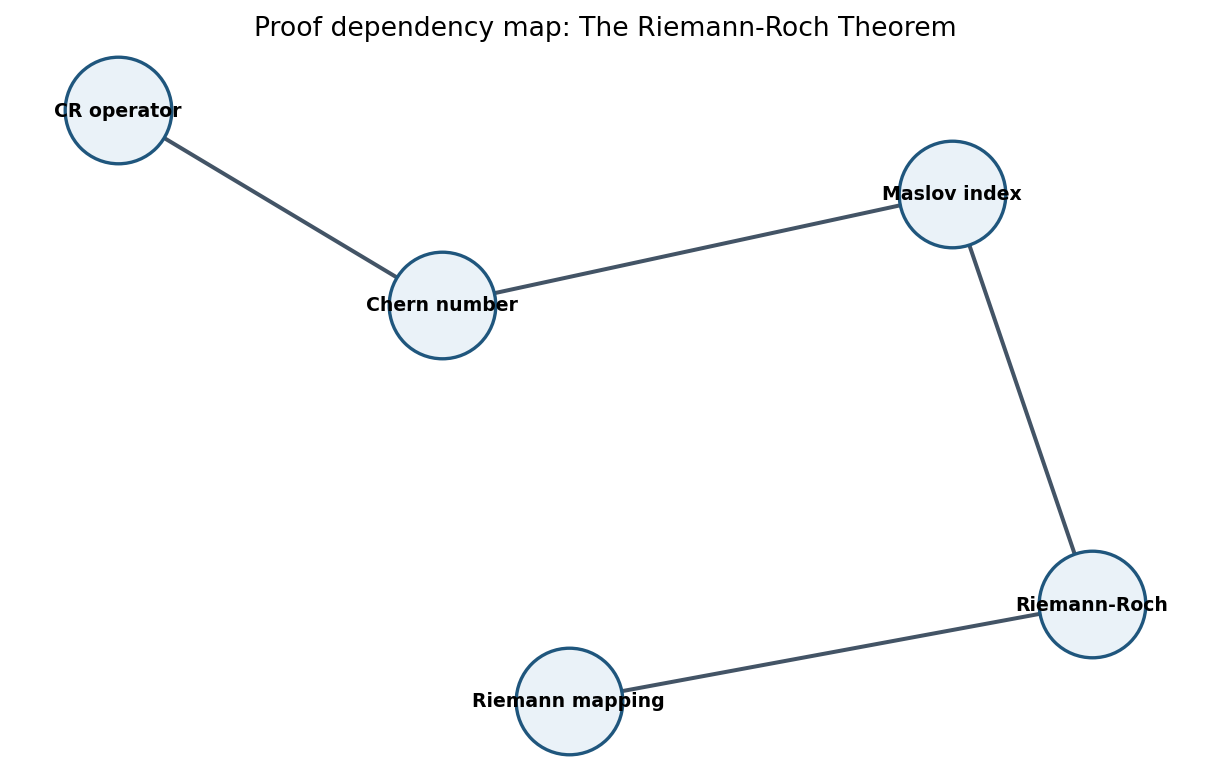

{'nodes': 5,
 'edges': 4,
 'is_directed_acyclic_graph': True,
 'source_span': '579-618',
 'passed': True}

In [2]:
CONCEPT_NODES = ['CR operator', 'Chern number', 'Maslov index', 'Riemann-Roch', 'Riemann mapping']
CONCEPT_EDGES = [('CR operator', 'Chern number'), ('Chern number', 'Maslov index'), ('Maslov index', 'Riemann-Roch'), ('Riemann-Roch', 'Riemann mapping')]

G = nx.DiGraph()
G.add_nodes_from(CONCEPT_NODES)
G.add_edges_from(CONCEPT_EDGES)
pos = nx.spring_layout(G, seed=34, k=1.35)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.8, edge_color="#435466")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2300, node_color="#eaf2f8", edgecolors="#1f567d", linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.5, font_weight="bold")
ax.set_title('Proof dependency map: The Riemann-Roch Theorem')
ax.set_axis_off()
graph_path = save_matplotlib(fig, UNIT, "figures", "proof-dependency-map.png")
plt.close(fig)

graph_check = {
    "nodes": len(CONCEPT_NODES),
    "edges": len(CONCEPT_EDGES),
    "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(G),
    "source_span": '579-618',
    "passed": len(CONCEPT_NODES) >= 5 and nx.is_directed_acyclic_graph(G),
}
graph_json = save_json(graph_check, UNIT, "checks", "proof-dependency-map.json")
display_artifact(graph_path, width=780)
graph_check


## Executable Model

This section builds a small model for one core mechanism in The Riemann-Roch Theorem. The model is intentionally finite and inspectable: it creates an artifact, records a JSON check, and gives a learner a parameter to perturb in the applied lab.


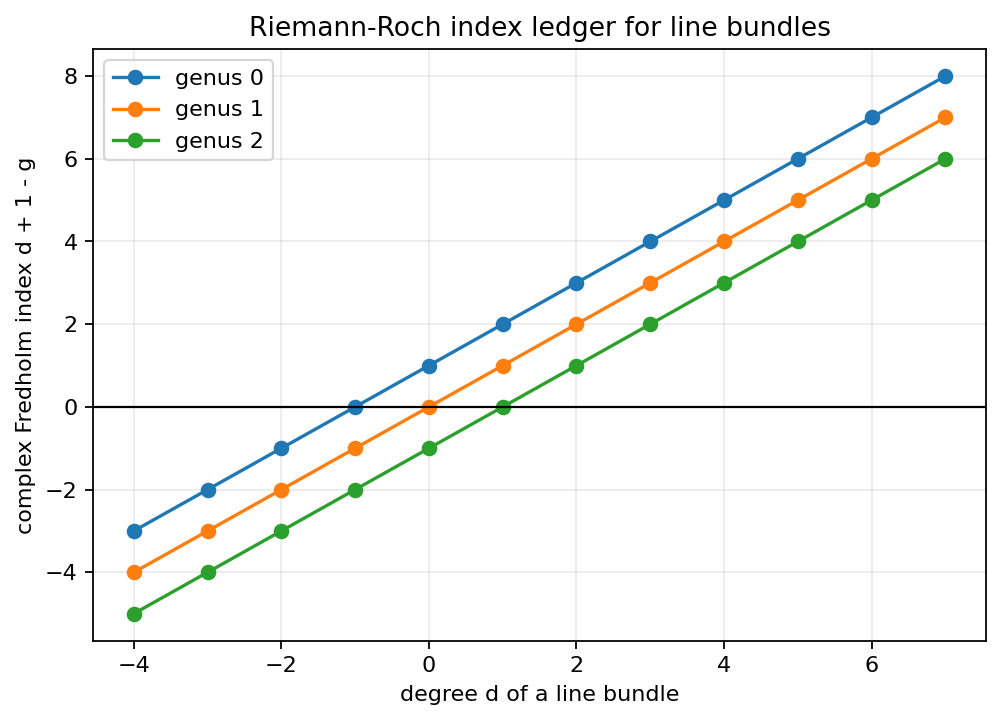

{'formula': 'index_complex = degree + 1 - genus for line bundles',
 'cases': [{'genus': 0, 'degree': -1, 'index': 0},
  {'genus': 0, 'degree': 0, 'index': 1},
  {'genus': 0, 'degree': 2, 'index': 3},
  {'genus': 0, 'degree': 5, 'index': 6},
  {'genus': 1, 'degree': -1, 'index': -1},
  {'genus': 1, 'degree': 0, 'index': 0},
  {'genus': 1, 'degree': 2, 'index': 2},
  {'genus': 1, 'degree': 5, 'index': 5},
  {'genus': 2, 'degree': -1, 'index': -2},
  {'genus': 2, 'degree': 0, 'index': -1},
  {'genus': 2, 'degree': 2, 'index': 1},
  {'genus': 2, 'degree': 5, 'index': 4}],
 'sphere_degree_0_index': 1,
 'passed': True}

In [3]:
degrees = np.arange(-4, 8)
genera = [0, 1, 2]
indices = {g: degrees + 1 - g for g in genera}

fig, ax = plt.subplots(figsize=(7.2, 4.8))
for g in genera:
    ax.plot(degrees, indices[g], marker="o", label=f"genus {g}")
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("degree d of a line bundle")
ax.set_ylabel("complex Fredholm index d + 1 - g")
ax.set_title("Riemann-Roch index ledger for line bundles")
ax.legend()
ax.grid(True, alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "riemann-roch-index-by-degree.png")
plt.close(fig)

check_cases = [{"genus": g, "degree": int(d), "index": int(d + 1 - g)} for g in genera for d in [-1, 0, 2, 5]]
check = {
    "formula": "index_complex = degree + 1 - genus for line bundles",
    "cases": check_cases,
    "sphere_degree_0_index": int(indices[0][np.where(degrees == 0)][0]),
    "passed": bool(indices[0][np.where(degrees == 0)][0] == 1 and indices[1][np.where(degrees == 0)][0] == 0),
}
check_path = save_json(check, UNIT, "checks", "riemann-roch-index-checks.json")
display_artifact(fig_path, width=700)
check


## Invariant Ledger

The ledger records the chapter vocabulary as computational objects plus explicit checks. It is a small source map inside the notebook: every row names what should be inspected when the figure or experiment is changed.


In [4]:
ledger_rows = [{'item': 'CR operator', 'computational_object': 'first-order elliptic operator', 'check': 'Fredholm index'}, {'item': 'Chern number', 'computational_object': 'degree of a complex line bundle', 'check': 'topological input'}, {'item': 'Maslov index', 'computational_object': 'boundary winding of Lagrangian condition', 'check': 'boundary contribution'}, {'item': 'Riemann-Roch', 'computational_object': 'index equals topology', 'check': 'formula check'}, {'item': 'Riemann mapping', 'computational_object': 'surface complex coordinate control', 'check': 'normal form'}]
table_path = TABLE_DIR / "invariant-ledger.csv"
with table_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=["item", "computational_object", "check"])
    writer.writeheader()
    writer.writerows(ledger_rows)

ledger_check = {
    "row_count": len(ledger_rows),
    "items": [row["item"] for row in ledger_rows],
    "has_source_specific_checks": all(row["check"] for row in ledger_rows),
    "passed": len(ledger_rows) >= 5 and all(row["check"] for row in ledger_rows),
}
ledger_json = save_json(ledger_check, UNIT, "checks", "invariant-ledger.json")
display_artifact(table_path)
ledger_check


{'row_count': 5,
 'items': ['CR operator',
  'Chern number',
  'Maslov index',
  'Riemann-Roch',
  'Riemann mapping'],
 'has_source_specific_checks': True,
 'passed': True}

## Applied Lab

Increase the genus while keeping degree fixed. The index drops by one per handle for a line bundle, matching the Euler-characteristic contribution.

The intended workflow is to change one parameter, rerun the executable model, and then inspect both the figure and JSON check. If the visual impression and the invariant check disagree, trust the check first and then ask what the visualization is hiding.


## Takeaways

    - Riemann-Roch is the topological source of many expected-dimension formulas.
- Chern and Maslov indices record interior and boundary twisting.
- Elliptic Fredholm theory is what allows the formula to control moduli spaces.

    ## Sanity Checks

    The final cell asserts that the generated figures, ledgers, and JSON checks exist, are nonempty, and report successful chapter-specific invariants.


In [5]:
expected = [
    FIG_DIR / "proof-dependency-map.png",
    FIG_DIR / 'riemann-roch-index-by-degree.png',
    CHECK_DIR / "proof-dependency-map.json",
    CHECK_DIR / 'riemann-roch-index-checks.json',
    CHECK_DIR / "invariant-ledger.json",
    TABLE_DIR / "invariant-ledger.csv",
]
for path in expected:
    min_bytes = 80 if path.suffix == ".csv" else 512
    assert_artifact(path, min_bytes=min_bytes)

for path in [CHECK_DIR / "proof-dependency-map.json", CHECK_DIR / 'riemann-roch-index-checks.json', CHECK_DIR / "invariant-ledger.json"]:
    data = json.loads(path.read_text(encoding="utf-8"))
    assert data.get("passed") is True, path

print(f"Validated {len(expected)} artifacts for {UNIT}")


Validated 6 artifacts for appendix-c
